**Import Libraries**

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [128]:
df = pd.read_csv('ford.csv')

In [129]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [130]:
df.shape

(17966, 9)

In [131]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='str')

In [132]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.2 MB


In [133]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [134]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

***EDA***

<Axes: xlabel='price', ylabel='Count'>

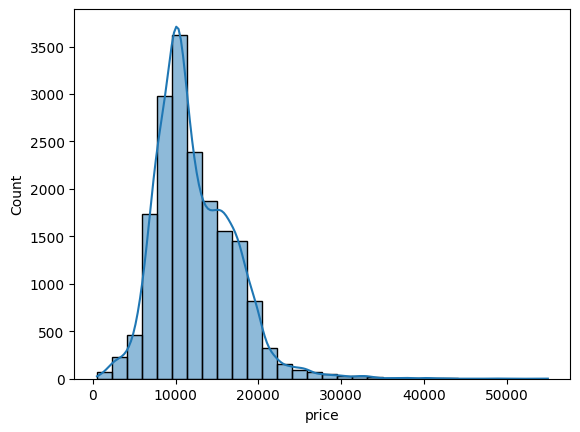

In [135]:
sns.histplot(df['price'], kde=True, bins=30)

<Axes: >

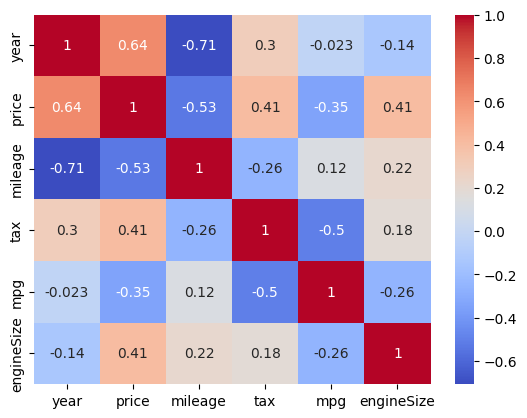

In [136]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

***Creating Boxplot to see correlation with each othe***

Text(0.5, 1.0, 'Price Distribution by Year')

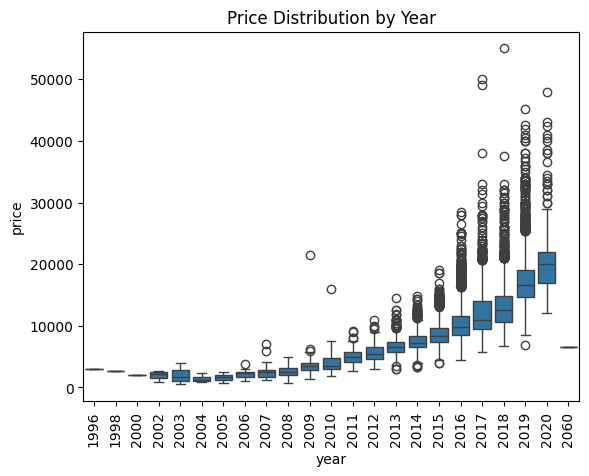

In [137]:
sns.boxplot(x='year', y='price', data=df) 
plt.xticks(rotation=90)
plt.title('Price Distribution by Year')

<Axes: xlabel='mileage', ylabel='price'>

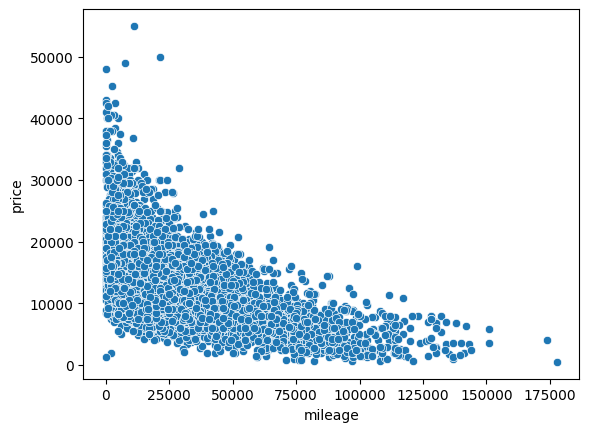

In [138]:
sns.scatterplot(data=df, x='mileage', y='price')

<Axes: xlabel='engineSize', ylabel='price'>

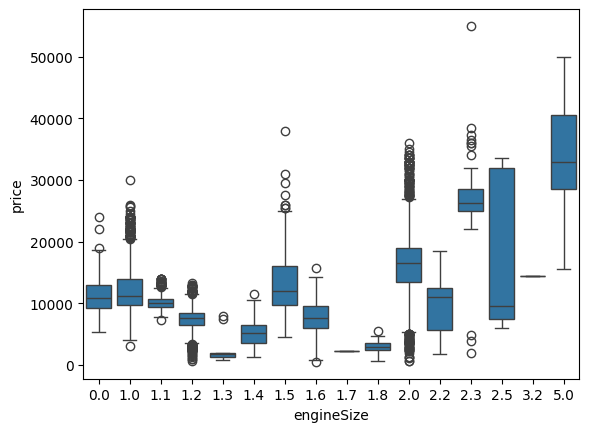

In [139]:
sns.boxplot(x='engineSize', y='price', data=df)

<Axes: xlabel='transmission', ylabel='price'>

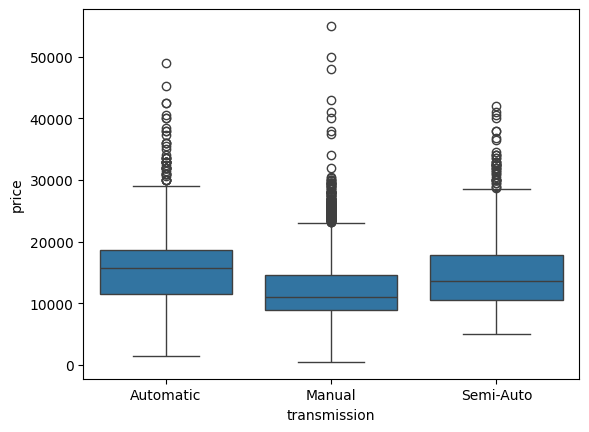

In [140]:
sns.boxplot(x='transmission', y='price', data=df)

<Axes: xlabel='fuelType', ylabel='price'>

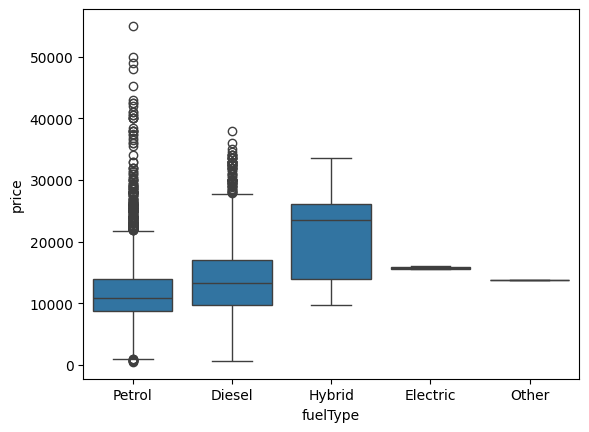

In [141]:
sns.boxplot(x='fuelType', y='price', data=df)


Text(0.5, 1.0, 'Price Distribution by Model')

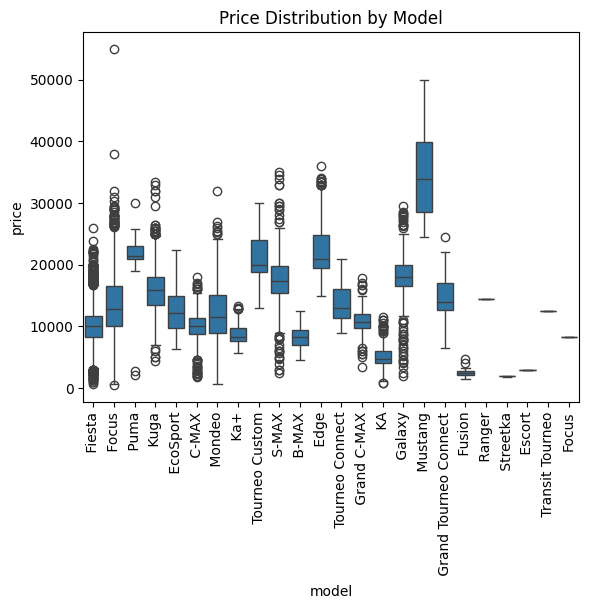

In [142]:
sns.boxplot(x='model', y='price', data=df)
plt.xticks(rotation=90)
plt.title('Price Distribution by Model')


Text(0.5, 1.0, 'Price Distribution by Model')

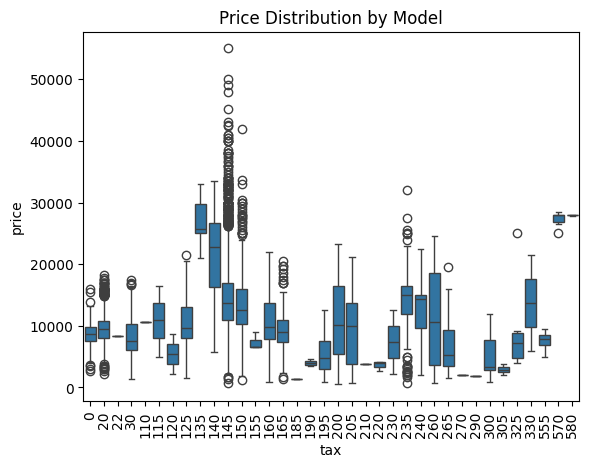

In [143]:
sns.boxplot(x='tax', y='price', data=df)
plt.xticks(rotation=90)
plt.title('Price Distribution by Model')


Text(0.5, 1.0, 'Price Distribution by Model')

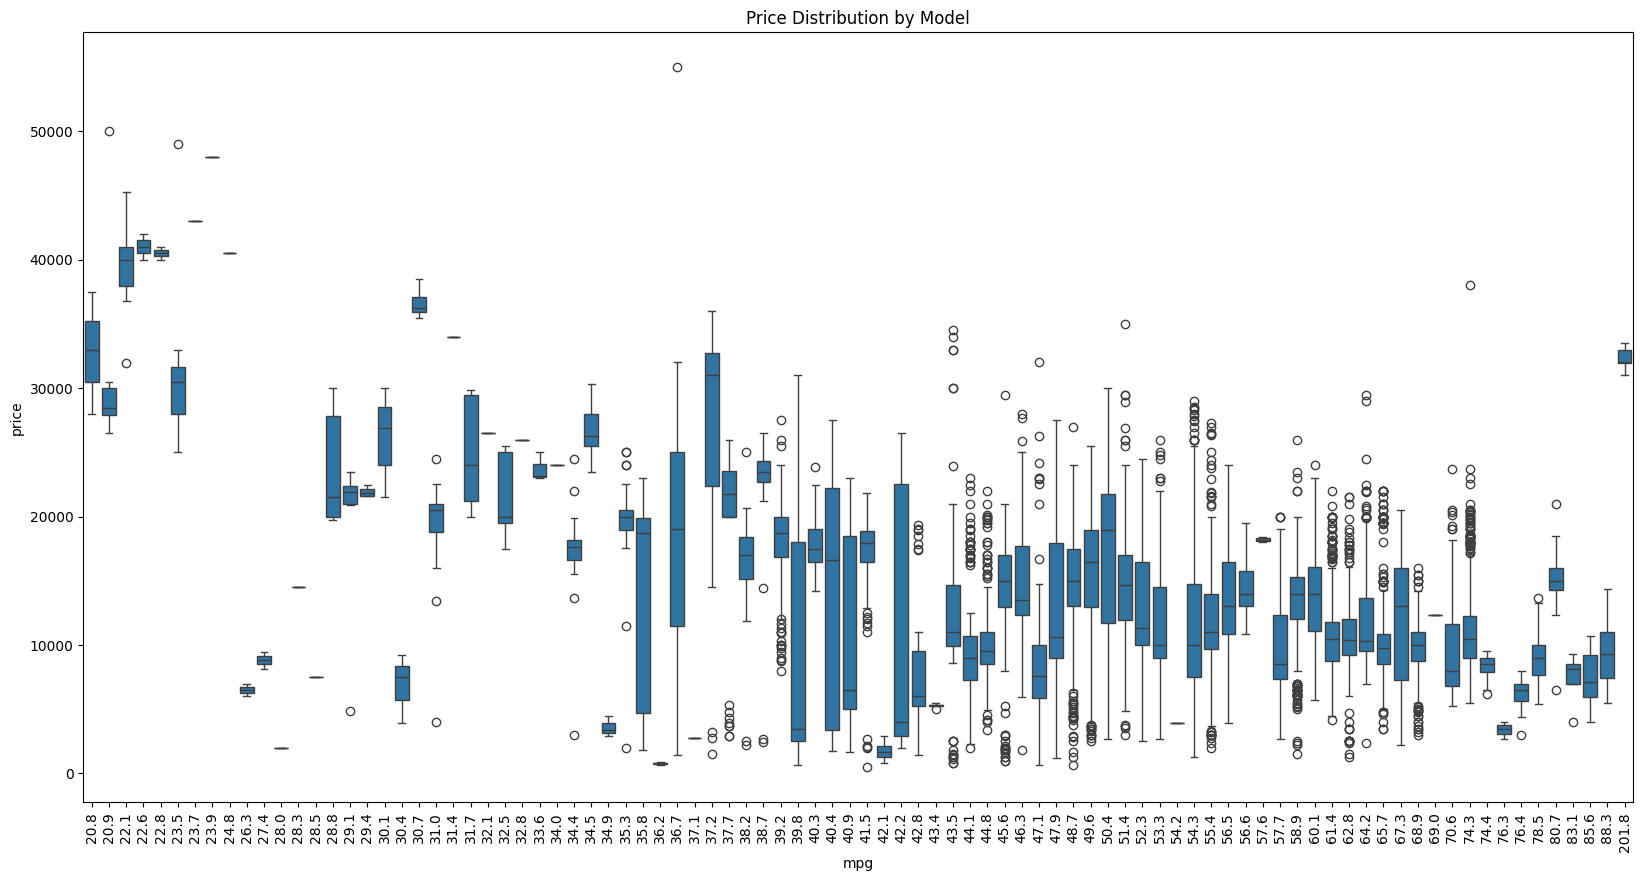

In [144]:
plt.figure(figsize=(20,10))
sns.boxplot(x='mpg', y='price', data=df)
plt.xticks(rotation=90)
plt.title('Price Distribution by Model')


***Adding Input and Output Features to a variable***

In [145]:
x = df.drop('price', axis=1)
y = df['price']

In [146]:
x.head(2)

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0


In [147]:
y.head(2)

0    12000
1    14000
Name: price, dtype: int64

***One hot encoding***

In [148]:
x_one_encode = pd.get_dummies(x, columns=['model', 'transmission', 'fuelType'], drop_first=True)

In [149]:
x_one_encode = x_one_encode.astype(int)

In [150]:
x_one_encode.head(2)

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


***Label Encoding***

In [151]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()

In [152]:
columns = ['model', 'transmission', 'fuelType']
x_label_encode = x.copy()

In [153]:
for i in columns:
    x_label_encode[i] = encode.fit_transform(x_label_encode[i])

In [154]:
x_label_encode.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0


***Importing standard scaler***

In [155]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numerical_cols = ['year', 'mileage', 'engineSize', 'tax', 'mpg']


x_one_encode[numerical_cols] = scaler.fit_transform(x_one_encode[numerical_cols])

In [156]:
x_one_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.042122,-0.447984,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.721198,-0.447984,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.931045,-0.447984,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.029814,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.398088,0.890398,-1.343791,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.910349,-0.839822,-1.505053,0.945569,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.552866,-0.942690,0.510727,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [157]:
x_label_encode.columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='str')

In [ ]:
x_label_encode[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']] = scaler.fit_transform(x_label_encode[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']])

In [159]:
x_label_encode

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386
...,...,...,...,...,...,...,...,...
17961,-1.706810,0.065128,0.041351,-0.342172,0.688777,0.591358,-1.067312,0.113779
17962,-1.706810,-1.398088,0.041351,0.890398,0.688777,-1.343791,-0.020442,-0.811386
17963,-0.211477,-0.910349,0.041351,-0.839822,-1.454098,-1.505053,0.927668,0.576362
17964,1.034634,0.552866,0.041351,-0.942690,0.688777,0.510727,-0.020442,-0.348804


***Creating Model With One Hot Encoded DF***

In [160]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [162]:
X_train, X_test, y_train, y_test = train_test_split(x_one_encode, y, test_size=0.33, random_state=42)

In [161]:
model = LinearRegression()

In [163]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [164]:
y_pred = model.predict(X_test)

In [165]:
y_pred

array([ 6888.75487917,  9328.62297666,  9420.53085767, ...,
       19099.96373064,  4948.44438264, 10424.59544226], shape=(5929,))

In [166]:
y_test

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
6015     19000
10301    10940
15006    21999
5396      6995
6087     10299
Name: price, Length: 5929, dtype: int64

In [167]:
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2:.4f}')

R-squared: 0.8397


In [168]:
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - x_one_encode.shape[1] - 1)
print(f'Adjusted R-squared: {adjusted_r2:.4f}')

Adjusted R-squared: 0.8387


***Creating Model With Label Hot Encoded DF***

In [170]:
X_train, X_test, y_train, y_test = train_test_split(x_label_encode, y, test_size=0.33, random_state=42)

In [171]:
model2 = LinearRegression()
model2.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [175]:
y_pred = model2.predict(X_test)

In [176]:
y_pred

array([ 6157.52473246,  9286.53653694,  9519.82817502, ...,
       19580.21385231,  7384.33202962,  9960.74790235], shape=(5929,))

In [177]:
y_test

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
6015     19000
10301    10940
15006    21999
5396      6995
6087     10299
Name: price, Length: 5929, dtype: int64

In [178]:
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2:.4f}')

R-squared: 0.7310


In [179]:
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - x_label_encode.shape[1] - 1)
print(f'Adjusted R-squared: {adjusted_r2:.4f}')

Adjusted R-squared: 0.7307
